In [ ]:
import csv
from pathlib import Path
from pprint import pprint
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('breast_cancer.csv')

Inicialmente, para entender o conjunto de dados e encontrar qualquer dado faltante, duplicatas ou absurdos, realizamos análises gerais que podem ser visualizadas abaixo. Todas as análises foram bem sucedidas, indicando uma base bem comportada.

In [ ]:
df.head()

,Unnamed: 0,mean_concave_points,mean_perimeter,mean_fractal_dimension,worst_perimeter,worst_texture,worst_area,target
0,0,0.14710,122.80,0.07871,184.60,17.33,2019.0,0
1,1,0.07017,132.90,0.05667,158.80,23.41,1956.0,0
2,2,0.12790,130.00,0.05999,152.50,25.53,1709.0,0
3,3,0.10520,77.58,0.09744,98.87,26.50,567.7,0
4,4,0.10430,135.10,0.05883,152.20,16.67,1575.0,0


In [ ]:
df.describe()

,Unnamed: 0,mean_concave_points,mean_perimeter,mean_fractal_dimension,worst_perimeter,worst_texture,worst_area,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,284.000000,0.048919,91.969033,0.062798,107.261213,25.677223,880.583128,0.627417
std,164.400426,0.038803,24.298981,0.007060,33.602542,6.146258,569.356993,0.483918
min,0.000000,0.000000,43.790000,0.049960,50.410000,12.020000,185.200000,0.000000
25%,142.000000,0.020310,75.170000,0.057700,84.110000,21.080000,515.300000,0.000000
50%,284.000000,0.033500,86.240000,0.061540,97.660000,25.410000,686.500000,1.000000
75%,426.000000,0.074000,104.100000,0.066120,125.400000,29.720000,1084.000000,1.000000
max,568.000000,0.201200,188.500000,0.097440,251.200000,49.540000,4254.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              569 non-null    int64  
 1   mean_concave_points     569 non-null    float64
 2   mean_perimeter          569 non-null    float64
 3   mean_fractal_dimension  569 non-null    float64
 4   worst_perimeter         569 non-null    float64
 5   worst_texture           569 non-null    float64
 6   worst_area              569 non-null    float64
 7   target                  569 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 35.7 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop(columns=['Unnamed: 0'])
df.columns

Index(['mean_concave_points', 'mean_perimeter', 'mean_fractal_dimension',
       'worst_perimeter', 'worst_texture', 'worst_area', 'target'],
      dtype='object')

Como todos as variavéis são numéricas, analisamos a dispersão de cada uma delas por meio de um histograma e um boxplot. Apenas a variável target, que é logística, fazia sentido apenas observar os totais ao longo da base de dados.

In [ ]:
def plot_hist_box(df, col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    axes[0].set_title(f'Histograma - {col}')

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot - {col}')

    fig.suptitle(col, fontsize=14)

    plt.tight_layout()
    plt.show()

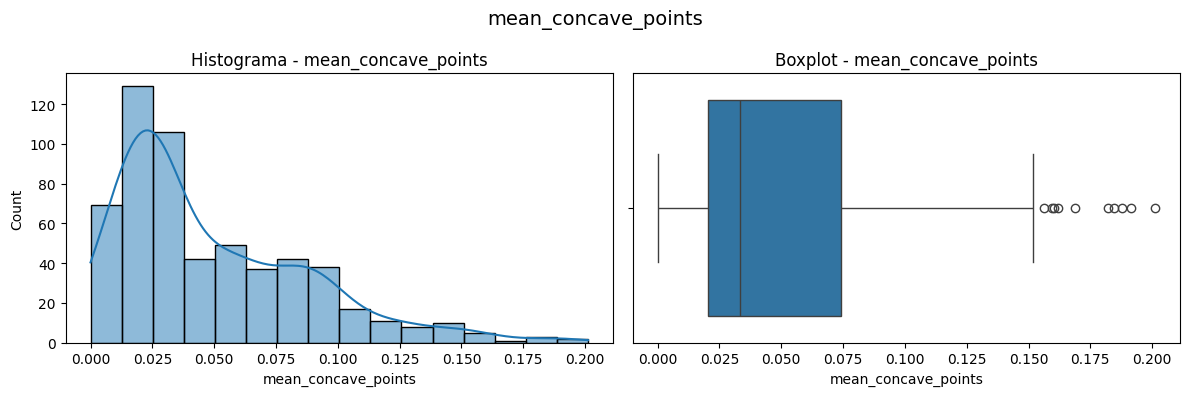

In [ ]:
plot_hist_box(df,'mean_concave_points')

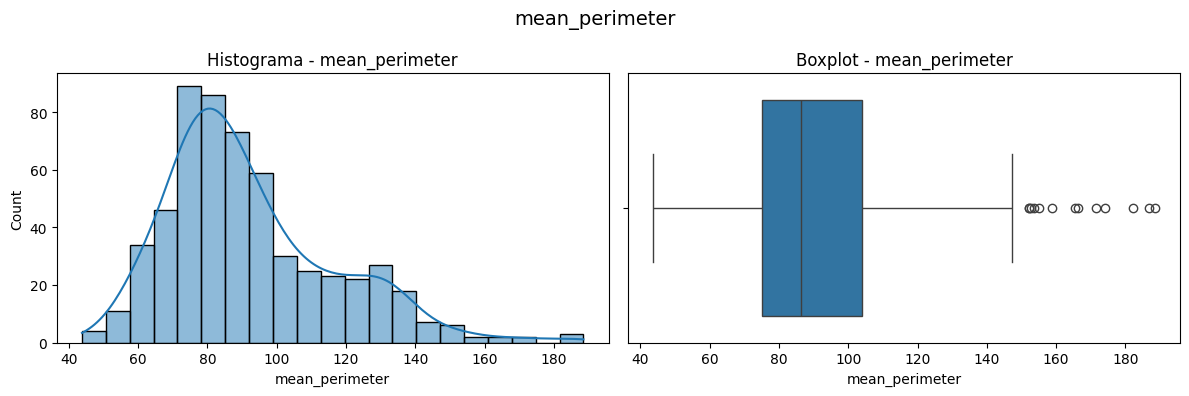

In [ ]:
plot_hist_box(df,'mean_perimeter')

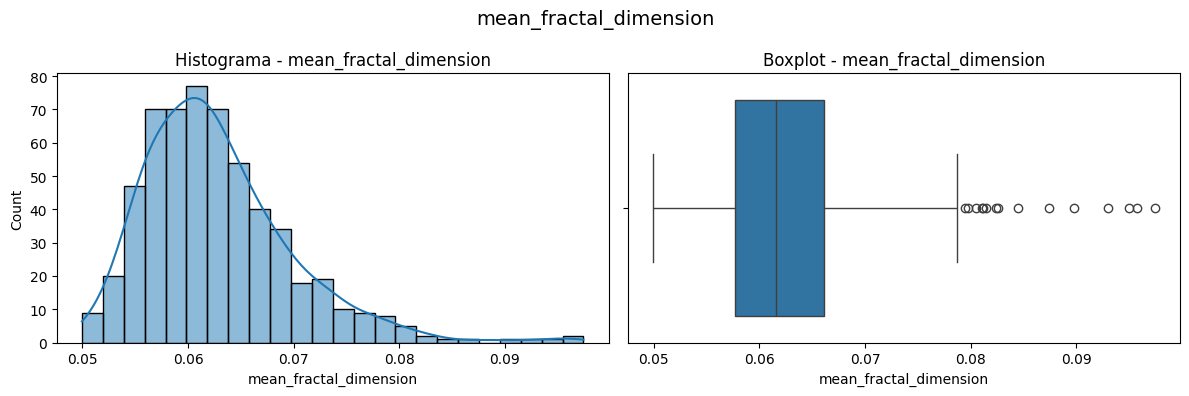

In [ ]:
plot_hist_box(df,'mean_fractal_dimension')

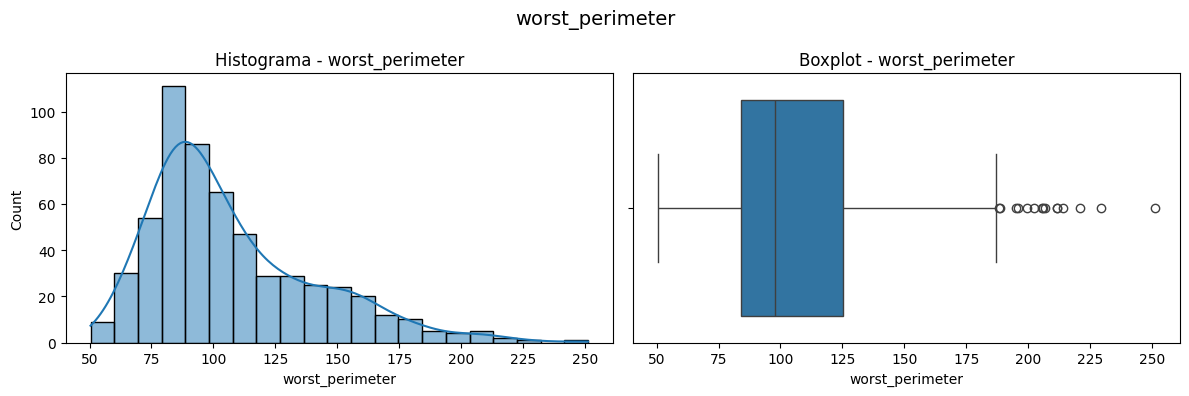

In [ ]:
plot_hist_box(df,'worst_perimeter')

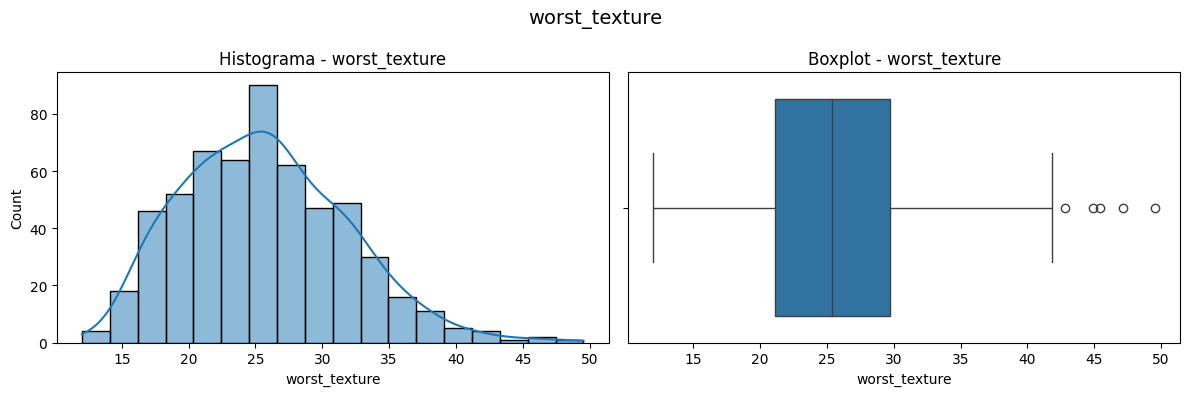

In [ ]:
plot_hist_box(df,'worst_texture')

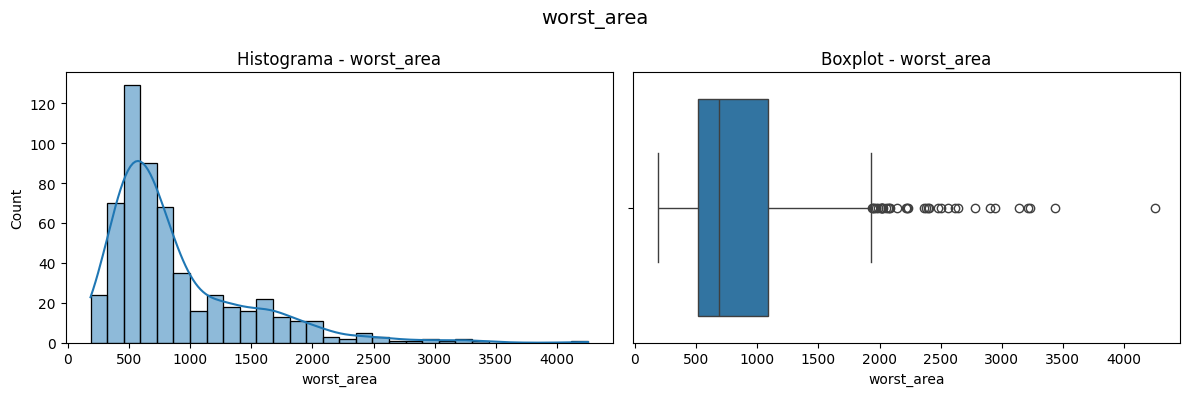

In [ ]:
plot_hist_box(df,'worst_area')

In [ ]:
tabela = (
    df['target']
    .value_counts()
    .to_frame('count')
    .assign(percent=lambda x: x['count'] * 100/ x['count'].sum())
)

tabela

,count,percent
target,,
1,357,62.741652
0,212,37.258348


Em seguida decidimos plotar uma matriz de correlação, indicandos os índices de correlação entre as variáveis observadas. Percebemos que as variáveis relacionadas ao tamanho do tumor, como *mean perimeter*, *worst perimeter* e *worst area*, apresentam **correlação forte e positiva entre si** (valores acima de 0.9 em alguns casos), indicando possível redundância de informação (multicolinearidade). O que pode impactar a modelagem

Em relação ao `target`, nota-se que a maioria das variáveis apresenta **correlação negativa forte**, como *mean concave points* (-0.78), *worst perimeter* (-0.78) e *mean perimeter* (-0.74). Considerando que o valor 1 representa tumores benignos e 0 malignos, essa correlação negativa indica que **valores mais altos dessas variáveis estão associados a tumores malignos**, enquanto valores mais baixos estão associados a tumores benignos. Esse padrão é consistente com a literatura, já que tumores malignos tendem a apresentar maior irregularidade e tamanho.



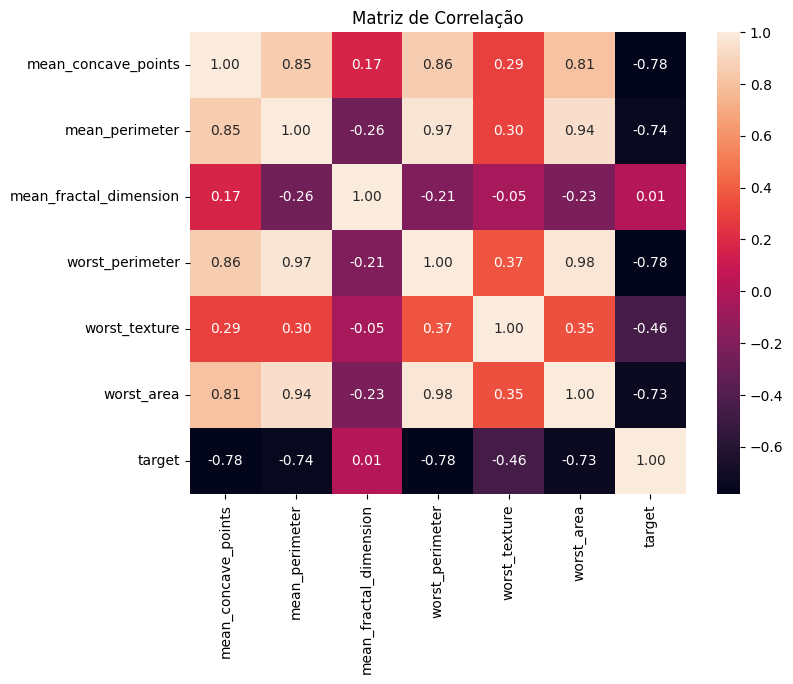

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

Em seguida, podemos observar pairplots, que permitem analisar simultaneamente a distribuição das variáveis e suas relações par a par, diferenciando os tumores benignos e malignos pela cor.

Observa-se que algumas variáveis apresentam boa capacidade de separação entre as classes, essas variáveis, em geral, possuem forte poder discriminatório entre tumores benignos e malignos.


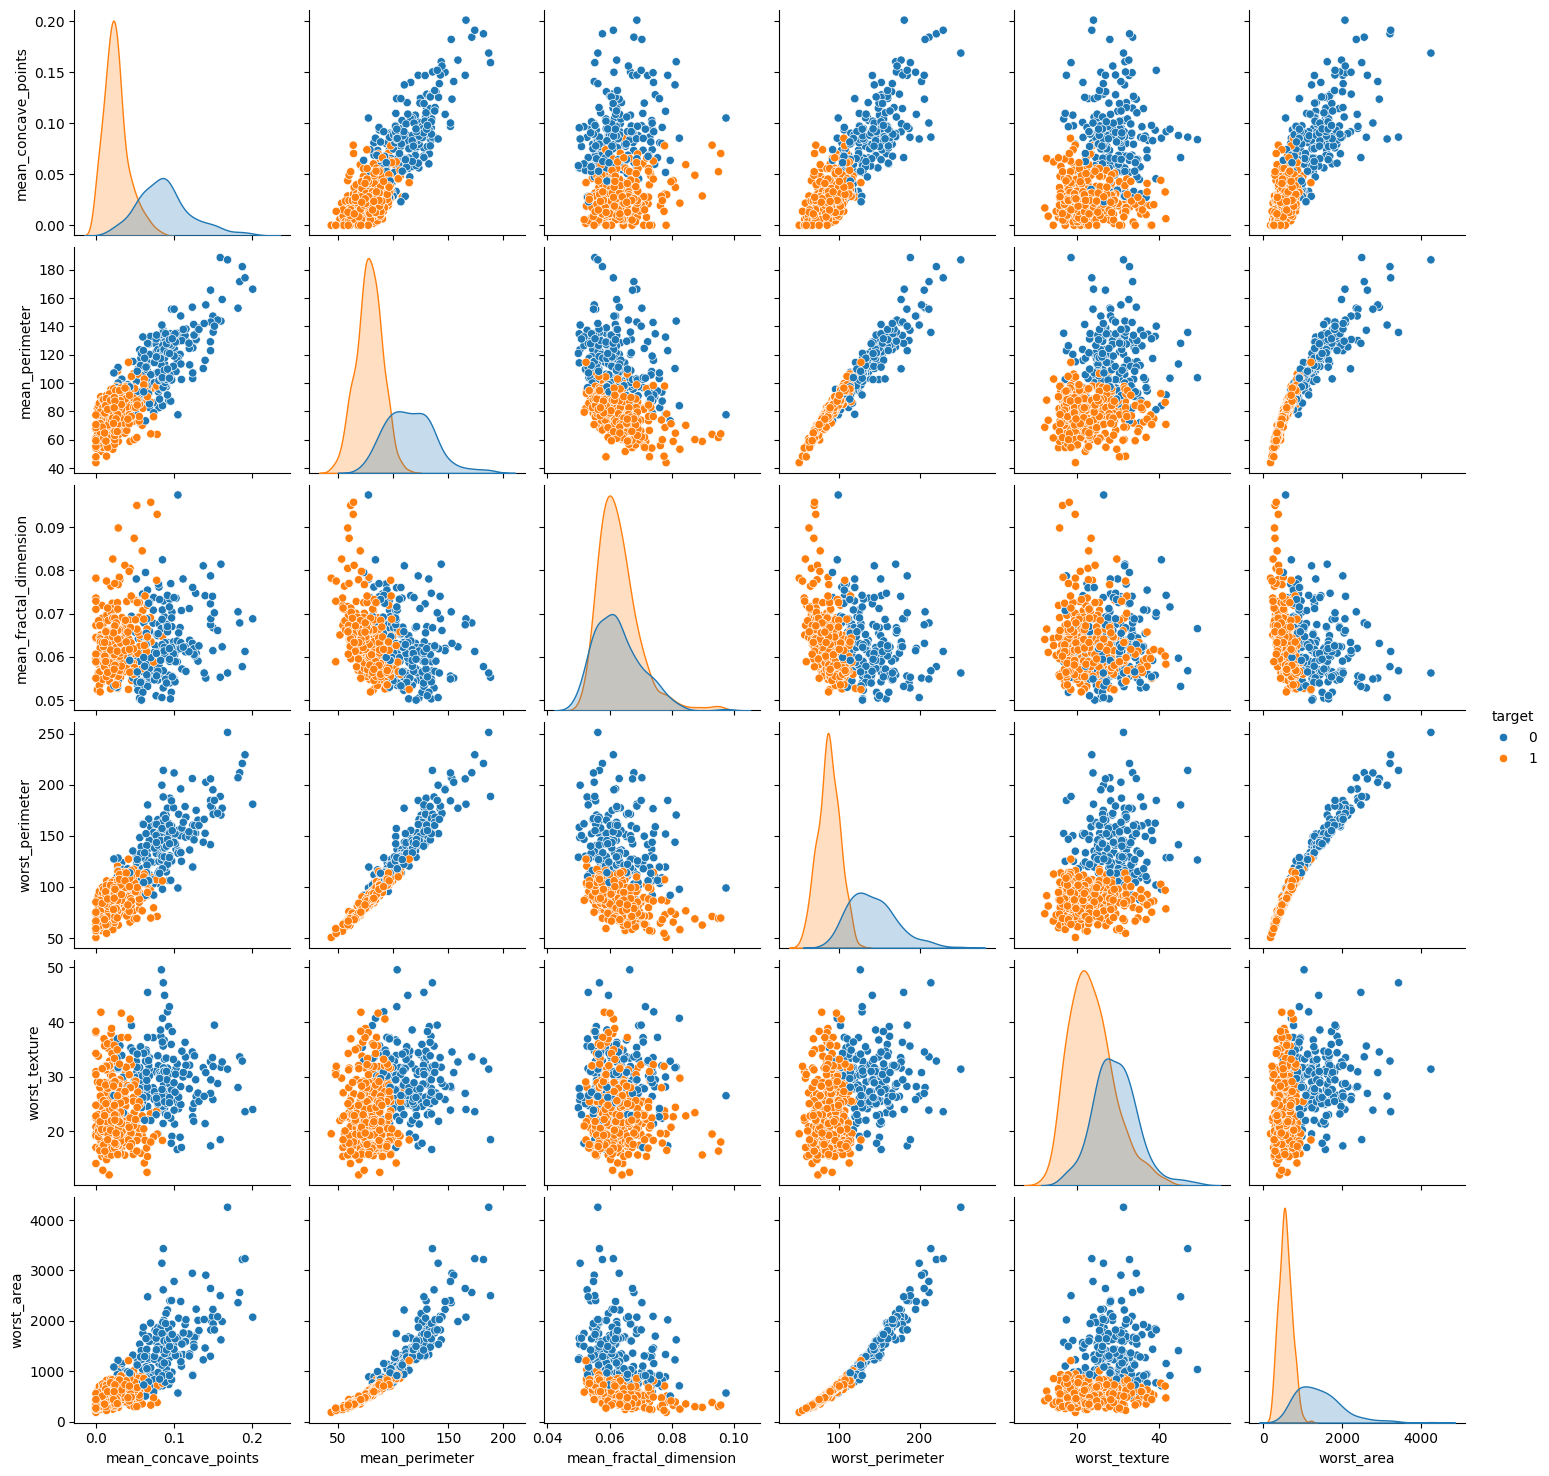

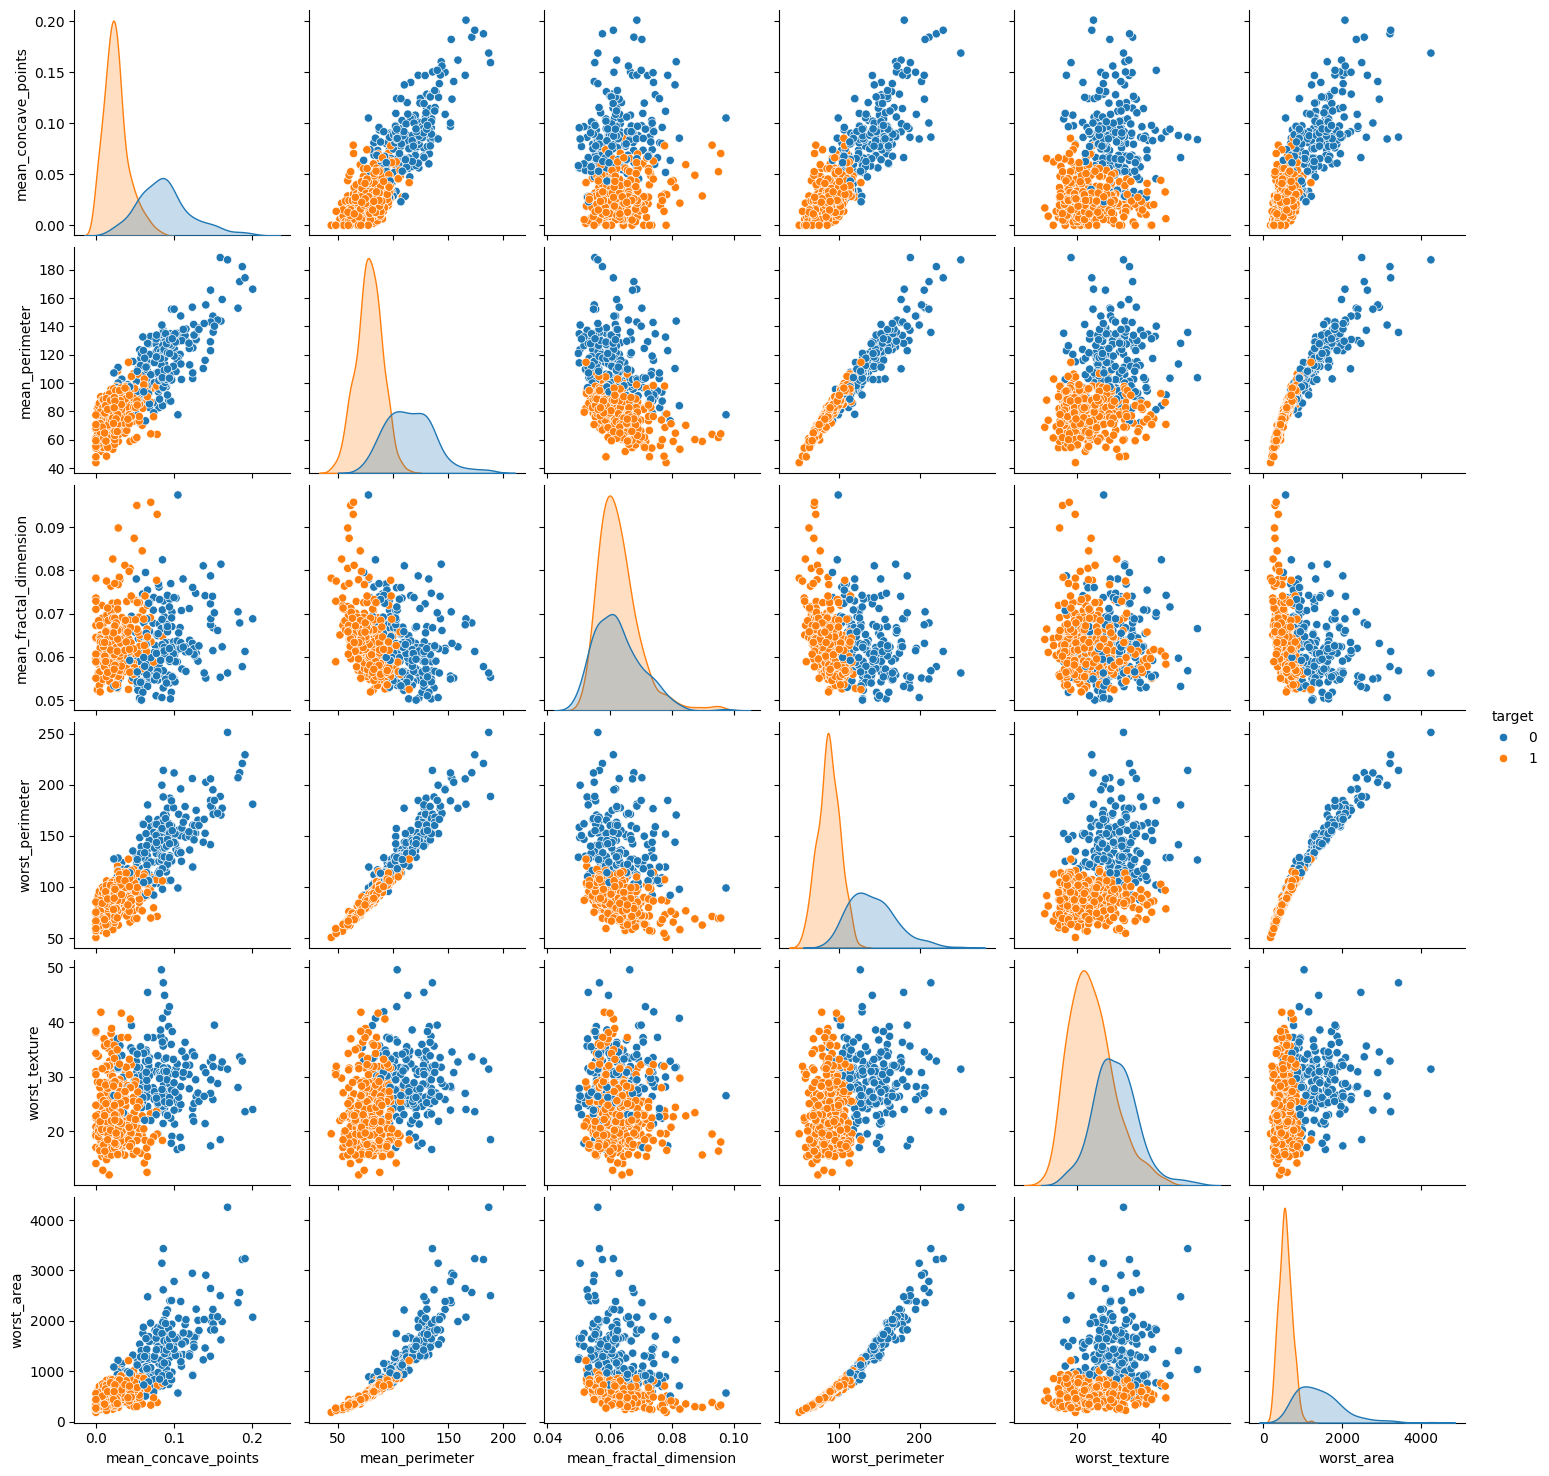

In [ ]:
sns.pairplot(df, hue='target')

g = sns.pairplot(df, hue='target')
g.savefig("pairplot.png")

Optei por realizar um VIF (Fator de Inflação da Variância) para avaliar a presença de multicolinearidade entre as variáveis estudadas. Observou-se que variáveis relacionadas ao tamanho do tumor, como worst perimeter, mean perimeter e worst area, apresentaram valores extremamente elevados de VIF, indicando forte redundância de informação.

Valores elevados de VIF implicam aumento na variância dos estimadores, tornando os coeficientes instáveis e dificultando a interpretação dos efeitos individuais das variáveis. Esse fenômeno causa inconsistências em modelos, como alterações na significância estatística e na magnitude dos coeficientes.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns='target')

vif = pd.DataFrame()
vif["variavel"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,variavel,VIF
0,mean_concave_points,8.060909
1,mean_perimeter,261.695188
2,mean_fractal_dimension,43.078446
3,worst_perimeter,589.245144
4,worst_texture,21.956045
5,worst_area,75.708306


Em seguida, podemos observar os indices de correlação em relação a target

In [ ]:
df.corr(numeric_only=True)['target'].abs().sort_values(ascending=False)


,target
target,1.000000
worst_perimeter,0.782914
mean_concave_points,0.776614
mean_perimeter,0.742636
worst_area,0.733825
worst_texture,0.456903
mean_fractal_dimension,0.012838


In [ ]:
import statsmodels.api as sm

X = df[['worst_perimeter', 'mean_concave_points', 'mean_perimeter','worst_area','mean_fractal_dimension','worst_texture']]
y = df['target']

# adicionar intercepto (IMPORTANTE no statsmodels)
X = sm.add_constant(X)

No modelo de regressão linear estimado, foram utilizadas como variáveis preditoras *worst_perimeter*, *mean_concave_points*, *mean_perimeter*, *worst_area*, *mean_fractal_dimension* e *worst_texture*. Todas apresentaram significância estatística ao nível de 5%, com exceção de *mean_fractal_dimension*, que foi apenas marginalmente significativa (p = 0.077), indicando evidência limitada de associação com a variável resposta.

Apesar do bom poder explicativo do modelo (R² ≈ 0.71), observa-se forte multicolinearidade, evidenciada pelo elevado *condition number* (2.52e+05) e pelos altos valores de VIF. Isso indica que variáveis relacionadas ao tamanho do tumor, como *worst_perimeter*, *mean_perimeter* e *worst_area*, são altamente correlacionadas entre si, comprometendo a estabilidade dos coeficientes e a confiabilidade dos testes de significância.

Diante disso, recomenda-se a redução do modelo, priorizando variáveis com maior associação com a resposta e menor redundância. Escolhemos por manter *worst_perimeter*, *mean_concave_points* e *worst_texture*, que representam diferentes características do tumor e resultam em um modelo mais estável.


In [ ]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     226.7
Date:                Tue, 05 May 2026   Prob (F-statistic):          1.76e-146
Time:                        21:17:08   Log-Likelihood:                -44.050
No. Observations:                 569   AIC:                             102.1
Df Residuals:                     562   BIC:                             132.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1

In [ ]:
import statsmodels.api as sm

X = df[['worst_perimeter', 'mean_concave_points', 'worst_texture']]
y = df['target']

# adicionar intercepto (IMPORTANTE no statsmodels)
X = sm.add_constant(X)

O modelo de regressão linear reduzido, utilizando as variáveis *worst_perimeter*, *mean_concave_points* e *worst_texture*, apresentou bom poder explicativo (R² ≈ 0.69), próximo ao modelo completo. Todas as variáveis incluídas são estatisticamente significativas (p < 0.001), indicando forte associação com o tipo de tumor.

Em comparação ao modelo anterior, observa-se redução do *condition number* (5.76e+03), sugerindo diminuição da multicolinearidade, embora ela ainda esteja presente em algum grau. De modo geral, o modelo se mostra mais estável e interpretável, mantendo bom desempenho com um conjunto menor de variáveis.


In [ ]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     423.9
Date:                Tue, 05 May 2026   Prob (F-statistic):          3.68e-144
Time:                        21:17:08   Log-Likelihood:                -58.486
No. Observations:                 569   AIC:                             125.0
Df Residuals:                     565   BIC:                             142.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.8437    

No modelo logístico completo, as variáveis preditoras consideradas foram worst_perimeter, mean_concave_points, mean_perimeter, worst_area, mean_fractal_dimension e worst_texture. Observa-se que mean_concave_points, mean_perimeter, worst_area e worst_texture são estatisticamente significativas (p < 0.05), enquanto worst_perimeter (p = 0.250) e mean_fractal_dimension (p = 0.295) não apresentam significância. A perda de significância de worst_perimeter, apesar de sua alta correlação com o desfecho, sugere forte multicolinearidade entre variáveis relacionadas ao tamanho do tumor, o que compromete a interpretação dos coeficientes.

In [ ]:
import statsmodels.api as sm

X = df[['worst_perimeter', 'mean_concave_points', 'mean_perimeter','worst_area','mean_fractal_dimension','worst_texture']]
y = df['target']

X = sm.add_constant(X)
model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                  569
Model:                            GLM   Df Residuals:                      562
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -40.101
Date:                Tue, 05 May 2026   Deviance:                       80.202
Time:                        21:17:08   Pearson chi2:                 4.51e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.6926
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      3

No modelo reduzido com mean_perimeter, mean_concave_points e worst_texture, todas as variáveis são estatisticamente significativas (p < 0.001), indicando associação robusta com o tipo de tumor. O modelo mantém bom poder explicativo (Pseudo R² ≈ 0.66) e apresenta maior estabilidade em comparação ao modelo completo. A remoção de variáveis redundantes reduz os efeitos da multicolinearidade, permitindo uma interpretação mais confiável dos coeficientes.

In [ ]:
import statsmodels.api as sm

X = df[['mean_perimeter', 'mean_concave_points', 'worst_texture']]
y = df['target']

X = sm.add_constant(X)
model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                  569
Model:                            GLM   Df Residuals:                      565
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -69.939
Date:                Tue, 05 May 2026   Deviance:                       139.88
Time:                        21:17:08   Pearson chi2:                     303.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6586
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  24.1416    

No modelo alternativo com *worst_perimeter*, *mean_concave_points* e *worst_texture*, todas as variáveis são estatisticamente significativas (p < 0.001), indicando que *worst_perimeter* recupera sua relevância quando não compete com outras variáveis altamente correlacionadas. Esse resultado reforça que sua ausência de significância no modelo completo era consequência da multicolinearidade. Além disso, este modelo apresenta Pseudo R² superior ao modelo com variáveis “mean”, indicando melhor capacidade explicativa. Em conjunto, os resultados sugerem que a versão “worst” das medidas de tamanho captura de forma mais informativa a diferença entre tumores, ao mesmo tempo em que mantém o modelo mais estável e interpretável, ao evitar redundâncias entre as variáveis.


In [ ]:
import statsmodels.api as sm

X = df[['worst_perimeter', 'mean_concave_points', 'worst_texture']]
y = df['target']

X = sm.add_constant(X)
model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                  569
Model:                            GLM   Df Residuals:                      565
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -54.406
Date:                Tue, 05 May 2026   Deviance:                       108.81
Time:                        21:17:08   Pearson chi2:                     554.
No. Iterations:                     9   Pseudo R-squ. (CS):             0.6768
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  28.8902    

Uma abordagem mais sistemática para a seleção de variáveis no modelo é a utilização do método **stepwise**. Esse procedimento busca identificar um subconjunto de variáveis que apresente bom poder explicativo, ao mesmo tempo em que evita redundâncias, utilizando critérios como o AIC (Akaike Information Criterion), que equilibra qualidade de ajuste e parcimônia.

O método pode ser aplicado de diferentes formas: iniciando com um modelo vazio e adicionando variáveis (*forward selection*), partindo de um modelo completo e removendo variáveis (*backward elimination*), ou combinando ambas as estratégias (*stepwise*). A cada etapa, o algoritmo avalia se a inclusão ou exclusão de uma variável melhora o critério escolhido, resultando em um modelo mais estável e interpretável.

No ambiente Python, não há uma implementação nativa tão direta desse procedimento quanto no R. Por esse motivo, foi utilizado um arquivo em RMarkdown que aplica o método stepwise ao problema em questão, permitindo uma seleção de variáveis mais estruturada e consistente.
